In [1]:
from utilities.data_loader import load_data

train_prices, train_dates, test_prices, test_dates = load_data("./data/BTC-Daily.csv")

We are going to determine a naive solution of Buy and Hold as benchmark for performance later

In [2]:
from optimizer.evaluator import execute_buy, execute_sell
_, btc_held = execute_buy(1000, test_prices[0], 0.03)
BUY_AND_HOLD_BENCHMARK, _ = execute_sell(btc_held, test_prices[-1], 0.03)
print(BUY_AND_HOLD_BENCHMARK)

5660.26318654683


In [3]:
import pandas as pd

fixed_results = pd.read_csv("results/fixed_runs.csv")
random_results = pd.read_csv("results/random_runs.csv")

In [4]:
df = pd.concat([fixed_results, random_results], ignore_index=True)

# Flip fitness because gps is maximizing not minimizing
df.loc[df["algo"] == "gps", "best_fitness"] *= -1

def fmt(x):
    if pd.isna(x):
        return "NaN"
    if abs(x) < 1e-7 or abs(x) > 9_999_999:
        return f"{x:.3e}"
    if x == 0:
        return "0"
    return f"{x:,.4f}"

stats = (
    df.groupby(['start_mode', 'algo', 'strategy'])['test_final_cash']
    .agg(count='count', mean='mean', std='std', var='var', min='min', median='median', max='max')
)
display(stats.map(fmt))

count        mean         std  \
start_mode algo strategy                                           
fixed      abo  ema_independent  30.0000  1,482.4498    994.6911   
                ema_shared       30.0000  1,815.8120  1,391.7397   
                lma              30.0000    683.1384    187.4051   
                sma              30.0000  1,172.2460     12.4752   
                weighted         30.0000  4,451.6966    817.0929   
           aos  ema_independent  30.0000  4,271.8511  1,401.7027   
                ema_shared       30.0000  1,894.0325  1,269.0238   
                lma              30.0000    794.0966    176.2895   
                sma              30.0000  1,172.2460     12.4752   
                weighted         30.0000  4,465.4214    830.2398   
           gps  ema_independent  30.0000  2,328.6670  1,619.2726   
                ema_shared       30.0000  1,831.8888  1,465.6274   
                lma              30.0000    879.1397    221.1375   
                sma              30.0000  1,154.9955    216.3662   
                weighted         30.0000  2,904.4636  1,852.4269   
           mrfo ema_independent  30.0000  1,000.0000   0.000e+00   
                ema_shared       30.0000  1,606.1015  1,366.8988   
                lma              30.0000    749.9327    200.3511   
                sma              30.0000  1,180.2757   0.000e+00   
                weighted         30.0000  4,329.0829  1,145.6547   
           pso  ema_independent  30.0000  3,219.7871  1,460.6491   
                ema_shared       30.0000  2,468.1415  2,176.0318   
                lma              30.0000    587.2506    135.8814   
                sma              30.0000  1,129.0634    142.7064   
                weighted         30.0000  4,813.3528    460.0434   
           sos  ema_independent  30.0000  3,805.2664  1,285.2927   
                ema_shared       30.0000  2,237.5683  1,698.3336   
                lma              30.0000    907.9777   0.000e+00   
                sma              30.0000  1,180.2757   0.000e+00   
                weighted         30.0000  4,580.5727    477.9724   
random     abo  ema_independent  30.0000  1,571.5479  1,116.9579   
                ema_shared       30.0000  2,408.1826  2,032.6657   
                lma              30.0000    742.4951    190.0496   
                sma              30.0000  1,171.3601     14.6123   
                weighted         30.0000  4,470.6795    970.3948   
           aos  ema_independent  30.0000  4,463.3594    911.8198   
                ema_shared       30.0000  2,559.5248  1,921.9903   
                lma              30.0000    804.3765    178.6373   
                sma              30.0000  1,169.5695     13.3366   
                weighted         30.0000  4,005.1364  1,513.4387   
           gps  ema_independent  30.0000  2,659.1735  1,639.7416   
                ema_shared       30.0000  1,819.9394  1,350.6767   
                lma              30.0000    939.1794    209.7797   
                sma              30.0000  1,052.9716    254.2962   
                weighted         30.0000  1,981.5014  1,767.2704   
           mrfo ema_independent  30.0000  1,000.0000   0.000e+00   
                ema_shared       30.0000  1,957.2996  2,195.3859   
                lma              30.0000    774.0242    195.3782   
                sma              30.0000  1,180.2757   0.000e+00   
                weighted         30.0000  4,158.1459  1,356.5596   
           pso  ema_independent  30.0000  3,321.9465  1,404.3073   
                ema_shared       30.0000  2,125.6139  1,431.4152   
                lma              30.0000    684.6731    176.2060   
                sma              30.0000  1,063.0738    211.9179   
                weighted         30.0000  4,464.4719  1,099.6319   
           sos  ema_independent  30.0000  4,148.7392  1,006.4116   
                ema_shared       30.0000  2,145.6082  1,907.3691   
                lma    

In [5]:
df = pd.concat([fixed_results, random_results], ignore_index=True)

# Flip fitness because gps is maximizing not minimizing
df.loc[df["algo"] == "gps", "best_fitness"] *= -1

def fmt(x):
    if pd.isna(x):
        return "NaN"
    if abs(x) < 1e-7 or abs(x) > 9_999_999:
        return f"{x:.3e}"
    if x == 0:
        return "0"
    return f"{x:,.4f}"

stats = (
    df.groupby(['algo', 'strategy'])['test_final_cash']
    .agg(count='count', mean='mean', std='std', var='var', min='min', median='median', max='max')
)

stats['cv'] = stats['std'] / stats['mean']

column_order = ['count', 'mean', 'std', 'cv', 'var', 'min', 'median', 'max']
stats = stats[column_order]

display(stats.map(fmt))


count        mean         std         cv  \
algo strategy                                                      
abo  ema_independent  60.0000  1,526.9988  1,049.5538     0.6873   
     ema_shared       60.0000  2,111.9973  1,752.7458     0.8299   
     lma              60.0000    712.8168    189.5040     0.2659   
     sma              60.0000  1,171.8031     13.4776     0.0115   
     weighted         60.0000  4,461.1881    889.4419     0.1994   
aos  ema_independent  60.0000  4,367.6053  1,176.3166     0.2693   
     ema_shared       60.0000  2,226.7786  1,649.2051     0.7406   
     lma              60.0000    799.2366    176.0332     0.2203   
     sma              60.0000  1,170.9077     12.8741     0.0110   
     weighted         60.0000  4,235.2789  1,232.2777     0.2910   
gps  ema_independent  60.0000  2,493.9202  1,624.2422     0.6513   
     ema_shared       60.0000  1,825.9141  1,397.3430     0.7653   
     lma              60.0000    909.1596    215.8327     0.2374   
     sma              60.0000  1,103.9835    239.6707     0.2171   
     weighted         60.0000  2,442.9825  1,854.2898     0.7590   
mrfo ema_independent  60.0000  1,000.0000   0.000e+00  0.000e+00   
     ema_shared       60.0000  1,781.7005  1,821.7421     1.0225   
     lma              60.0000    761.9784    196.5719     0.2580   
     sma              60.0000  1,180.2757   0.000e+00  0.000e+00   
     weighted         60.0000  4,243.6144  1,247.8379     0.2941   
pso  ema_independent  60.0000  3,270.8668  1,421.4949     0.4346   
     ema_shared       60.0000  2,296.8777  1,834.2214     0.7986   
     lma              60.0000    635.9619    163.5529     0.2572   
     sma              60.0000  1,096.0686    182.1842     0.1662   
     weighted         60.0000  4,638.9124    854.0020     0.1841   
sos  ema_independent  60.0000  3,977.0028  1,157.5106     0.2911   
     ema_shared       60.0000  2,191.5883  1,791.1093     0.8173   
     lma              60.0000    907.9777   0.000e+00  0.000e+00   
     sma              60.0000  1,180.2757   0.000e+00  0.000e+00   
     weighted         60.0000  4,627.9653    338.6972     0.0732   

                                 var         min      median          max  
algo strategy                                                              
abo  ema_independent  1,101,563.2255    858.1458  1,230.9716   4,360.9038  
     ema_shared       3,072,117.8230    554.4727  1,126.9016   7,795.0728  
     lma                 35,911.7771    487.7403    671.5093     907.9777  
     sma                    181.6459  1,126.9329  1,180.2757   1,180.2757  
     weighted           791,106.8499  1,130.4039  4,651.6147   5,853.4885  
aos  ema_independent  1,383,720.6856    977.9262  4,389.7988   7,478.4555  
     ema_shared       2,719,877.5509    603.2835  1,241.9622   7,860.3811  
     lma                 30,987.7009    485.4056    907.9777     921.2818  
     sma                    165.7433  1,153.5101  1,180.2757   1,180.2757  
     weighted         1,518,508.2771    743.9536  4,600.2042   5,737.9722  
gps  ema_independent  2,638,162.8324    509.7981  2,068.9386   5,684.3164  
     ema_shared       1,952,567.5538    462.4916  1,149.2203   4,584.5951  
     lma                 46,583.7527    378.9697    948.0774   1,373.4670  
     sma                 57,442.0261    520.3787  1,056.9681   1,857.1386  
     weighted         3,438,390.8330    301.0823  1,784.8386   5,610.7465  
mrfo ema_independent       0.000e+00  1,000.0000  1,000.0000   1,000.0000  
     ema_shared       3,318,744.3346    484.1837  1,000.0000  11,973.2027  
     lma                 38,640.4953    487.7403    907.9777     907.9777  
     sma                   0.000e+00  1,180.2757  1,180.2757   1,180.2757  
     weighted         1,557,099.4912    977.2400  4,711.2873   5,680.5246  
pso  ema_independent  2,020,647.7265  1,201.2297  4,296.9697   4,565.8008  
     ema_shared       3,364,368.1728    718.5621  1,239.3350  10,074.6391  
     lma               

Sort by Strategy and CV for only fixed point initialization

In [6]:
df = pd.concat([fixed_results, random_results], ignore_index=True)

# Flip fitness because gps is maximizing not minimizing
df.loc[df["algo"] == "gps", "best_fitness"] *= -1

def fmt(x):
    if pd.isna(x):
        return "NaN"
    if abs(x) < 1e-7 or abs(x) > 9_999_999:
        return f"{x:.3e}"
    if x == 0:
        return "0"
    return f"{x:,.4f}"

stats = (
    df.groupby(['algo', 'strategy','start_mode'])['test_final_cash']
    .agg(count='count', mean='mean', std='std', var='var', min='min', median='median', max='max')
)

stats['cv'] = stats['std'] / stats['mean']


stats = stats.sort_values(by=[('strategy'), 'cv'], ascending=[True, True])

fixed_stats = stats.xs('fixed', level='start_mode')

column_order = ['count', 'mean', 'std', 'cv', 'min', 'median', 'max']


# Display formatted table
display(fixed_stats.map(fmt))

,,count,mean,std,var,min,median,max,cv
algo,strategy,,,,,,,,
mrfo,ema_independent,30.0000,"1,000.0000",0.000e+00,0.000e+00,"1,000.0000","1,000.0000","1,000.0000",0.000e+00
aos,ema_independent,30.0000,"4,271.8511","1,401.7027","1,964,770.5024",977.9262,"4,425.3908","7,478.4555",0.3281
sos,ema_independent,30.0000,"3,805.2664","1,285.2927","1,651,977.3254","1,206.8093","4,296.9697","4,834.2114",0.3378
pso,ema_independent,30.0000,"3,219.7871","1,460.6491","2,133,495.7079","1,201.2297","4,296.9697","4,565.8008",0.4536
abo,ema_independent,30.0000,"1,482.4498",994.6911,"989,410.4156",858.1458,"1,202.4195","4,360.9038",0.6710
gps,ema_independent,30.0000,"2,328.6670","1,619.2726","2,622,043.6733",509.7981,"1,588.7568","5,684.3164",0.6954
aos,ema_shared,30.0000,"1,894.0325","1,269.0238","1,610,421.4700",603.2835,"1,137.1210","4,377.1504",0.6700
sos,ema_shared,30.0000,"2,237.5683","1,698.3336","2,884,337.1312",617.0044,"1,862.0257","7,142.0901",0.7590
abo,ema_shared,30.0000,"1,815.8120","1,391.7397","1,936,939.2930",633.3265,"1,157.6009","6,138.8757",0.7665


In [7]:
df = pd.concat([fixed_results, random_results], ignore_index=True)

# Flip fitness because gps is maximizing not minimizing
df.loc[df["algo"] == "gps", "best_fitness"] *= -1

def fmt(x):
    if pd.isna(x):
        return "NaN"
    if abs(x) < 1e-7 or abs(x) > 9_999_999:
        return f"{x:.3e}"
    if x == 0:
        return "0"
    return f"{x:,.4f}"

stats = (
    df.groupby(['algo', 'strategy'])['final_cash']
    .agg(count='count', mean='mean', std='std', var='var', min='min', median='median', max='max')
)

stats['cv'] = stats['std'] / stats['mean']

column_order = ['count', 'mean', 'std', 'cv', 'var', 'min', 'median', 'max']
stats = stats[column_order]

display(stats.map(fmt))

count          mean          std         cv  \
algo strategy                                                         
abo  ema_independent  60.0000   10,451.2594   1,410.1391     0.1349   
     ema_shared       60.0000   78,292.1552  26,994.4963     0.3448   
     lma              60.0000      803.5605      16.0150     0.0199   
     sma              60.0000      932.0520       0.7789     0.0008   
     weighted         60.0000   11,278.6130   1,213.0586     0.1076   
aos  ema_independent  60.0000    7,651.5132   1,180.3813     0.1543   
     ema_shared       60.0000   55,573.4874  20,591.3033     0.3705   
     lma              60.0000      807.0245      14.5812     0.0181   
     sma              60.0000      932.0346       0.6358     0.0007   
     weighted         60.0000   13,553.9315   7,512.8355     0.5543   
gps  ema_independent  60.0000    4,737.8806   3,867.3022     0.8163   
     ema_shared       60.0000   12,603.0155  10,152.4112     0.8056   
     lma              60.0000      448.9692     121.0907     0.2697   
     sma              60.0000      549.1785     119.4122     0.2174   
     weighted         60.0000    4,891.2023   3,608.3322     0.7377   
mrfo ema_independent  60.0000    1,000.0000    0.000e+00  0.000e+00   
     ema_shared       60.0000   70,592.7926  21,197.6475     0.3003   
     lma              60.0000      810.4937      12.0347     0.0148   
     sma              60.0000      932.4972    0.000e+00  0.000e+00   
     weighted         60.0000   26,878.8156  29,060.8536     1.0812   
pso  ema_independent  60.0000   12,249.1975   1,098.6018     0.0897   
     ema_shared       60.0000   88,994.2994  28,052.0123     0.3152   
     lma              60.0000      796.0960      16.1937     0.0203   
     sma              60.0000      909.6627      48.1545     0.0529   
     weighted         60.0000   12,615.2683   1,256.7719     0.0996   
sos  ema_independent  60.0000   12,719.8382     988.6782     0.0777   
     ema_shared       60.0000  103,597.1136  25,471.1550     0.2459   
     lma              60.0000      818.9286    0.000e+00  0.000e+00   
     sma              60.0000      932.4972    0.000e+00  0.000e+00   
     weighted         60.0000   22,443.1600   6,485.4846     0.2890   

                                 var          min        median           max  
algo strategy                                                                  
abo  ema_independent  1,988,492.1716   5,967.6358   10,438.4060   13,212.5322  
     ema_shared            7.287e+08  31,561.6441   74,432.6899  200,371.4157  
     lma                    256.4796     776.2630      800.1090      818.9286  
     sma                      0.6066     928.2573      932.4972      932.4972  
     weighted         1,471,511.0897   7,967.2923   11,291.1168   14,081.5780  
aos  ema_independent  1,393,299.9952   5,678.1824    7,777.4558   10,581.4517  
     ema_shared            4.240e+08  29,400.2438   50,334.0483  132,228.7700  
     lma                    212.6121     767.3220      817.5486      818.9286  
     sma                      0.4043     931.1753      932.4972      932.4972  
     weighted              5.644e+07   9,677.1107   10,670.0063   47,446.8320  
gps  ema_independent       1.496e+07     293.7361    4,281.4338   12,939.6909  
     ema_shared            1.031e+08     442.9367    9,284.2141   44,225.3490  
     lma                 14,662.9529     112.8109      445.5503      768.2639  
     sma                 14,259.2839     300.6499      572.2748      917.9666  
     weighted              1.302e+07     102.8537    5,299.3775   10,389.2061  
mrfo ema_independent       0.000e+00   1,000.0000    1,000.0000    1,000.0000  
     ema_shared            4.493e+08  40,486.2250   66,026.2713  171,987.5764  
     lma                    144.8329     772.3781      818.9286      818.9286  
     sma                   0.000e+00     932.4972      932.4972      932.4972  
     weighted              8.445e+08  10,692.7447   12,014.3316  104,91

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Kruskal Wallis

In [9]:
from scipy.stats import kruskal
import pandas as pd

results = []

for strategy in df['strategy'].unique():
    for init in df['start_mode'].unique():
        subset = df.query("strategy == @strategy and start_mode == @init")
        groups = [g['best_fitness'].values for _, g in subset.groupby('algo')]
        
        stat, p = kruskal(*groups)
        results.append({
            'strategy': strategy,
            'start_mode': init,
            'H_stat': stat,
            'p_value': p,
            'significant': p < 0.05
        })

results_df = pd.DataFrame(results)
display(results_df)

,strategy,start_mode,H_stat,p_value,significant
0,sma,fixed,119.065414,4.950704e-24,True
1,sma,random,121.153144,1.788376e-24,True
2,lma,fixed,114.624910,4.310926e-23,True
3,lma,random,106.187071,2.617626e-21,True
4,ema_shared,fixed,114.929809,3.715893e-23,True
5,ema_shared,random,114.235384,5.211656e-23,True
6,ema_independent,fixed,151.732904,5.709724e-31,True
7,ema_independent,random,144.008592,2.513903e-29,True
8,weighted,fixed,120.694330,2.236958e-24,True
9,weighted,random,120.876481,2.046777e-24,True


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scikit_posthocs import posthoc_dunn

def paired_posthoc(value_column):
    strategies = df['strategy'].unique()
    start_modes = df['start_mode'].unique()

    combinations = [(s, m) for s in strategies for m in start_modes]
    n_combos = len(combinations)

    # Grid layout
    ncols = 2
    nrows = (n_combos + 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 5))
    axes = axes.flatten()

    for i, (strategy, start_mode) in enumerate(combinations):
        subset = df.query("strategy == @strategy and start_mode == @start_mode")
        
        dunn_result = posthoc_dunn(
            subset,
            val_col=value_column,
            group_col='algo',
            p_adjust='bonferroni'
        )
        
        mask = np.triu(np.ones_like(dunn_result, dtype=bool))
        
        sns.heatmap(
            dunn_result,
            mask=mask,
            annot=True,
            fmt='.2e',
            cmap='RdYlGn',
            vmin=0,
            vmax=0.05,
            linewidths=0.5,
            ax=axes[i],
            cbar_kws={'label': 'p-value'},
            annot_kws={'size': 8}
        )
        
        axes[i].set_title(
            f"strategy={strategy} | init={start_mode}",
            fontsize=10, fontweight='bold'
        )
        axes[i].tick_params(axis='x', rotation=45, labelsize=8)
        axes[i].tick_params(axis='y', rotation=0, labelsize=8)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(
        "Dunn's Post-hoc Pairwise Test — All Strategy × Init Combinations\n"
        "Red = significantly different (p < 0.05) | Green = no significant difference",
        fontsize=12, fontweight='bold', y=1.02
    )

    plt.tight_layout()
    plt.savefig('dunn_pairwise_all.png', dpi=150, bbox_inches='tight')
    plt.show()

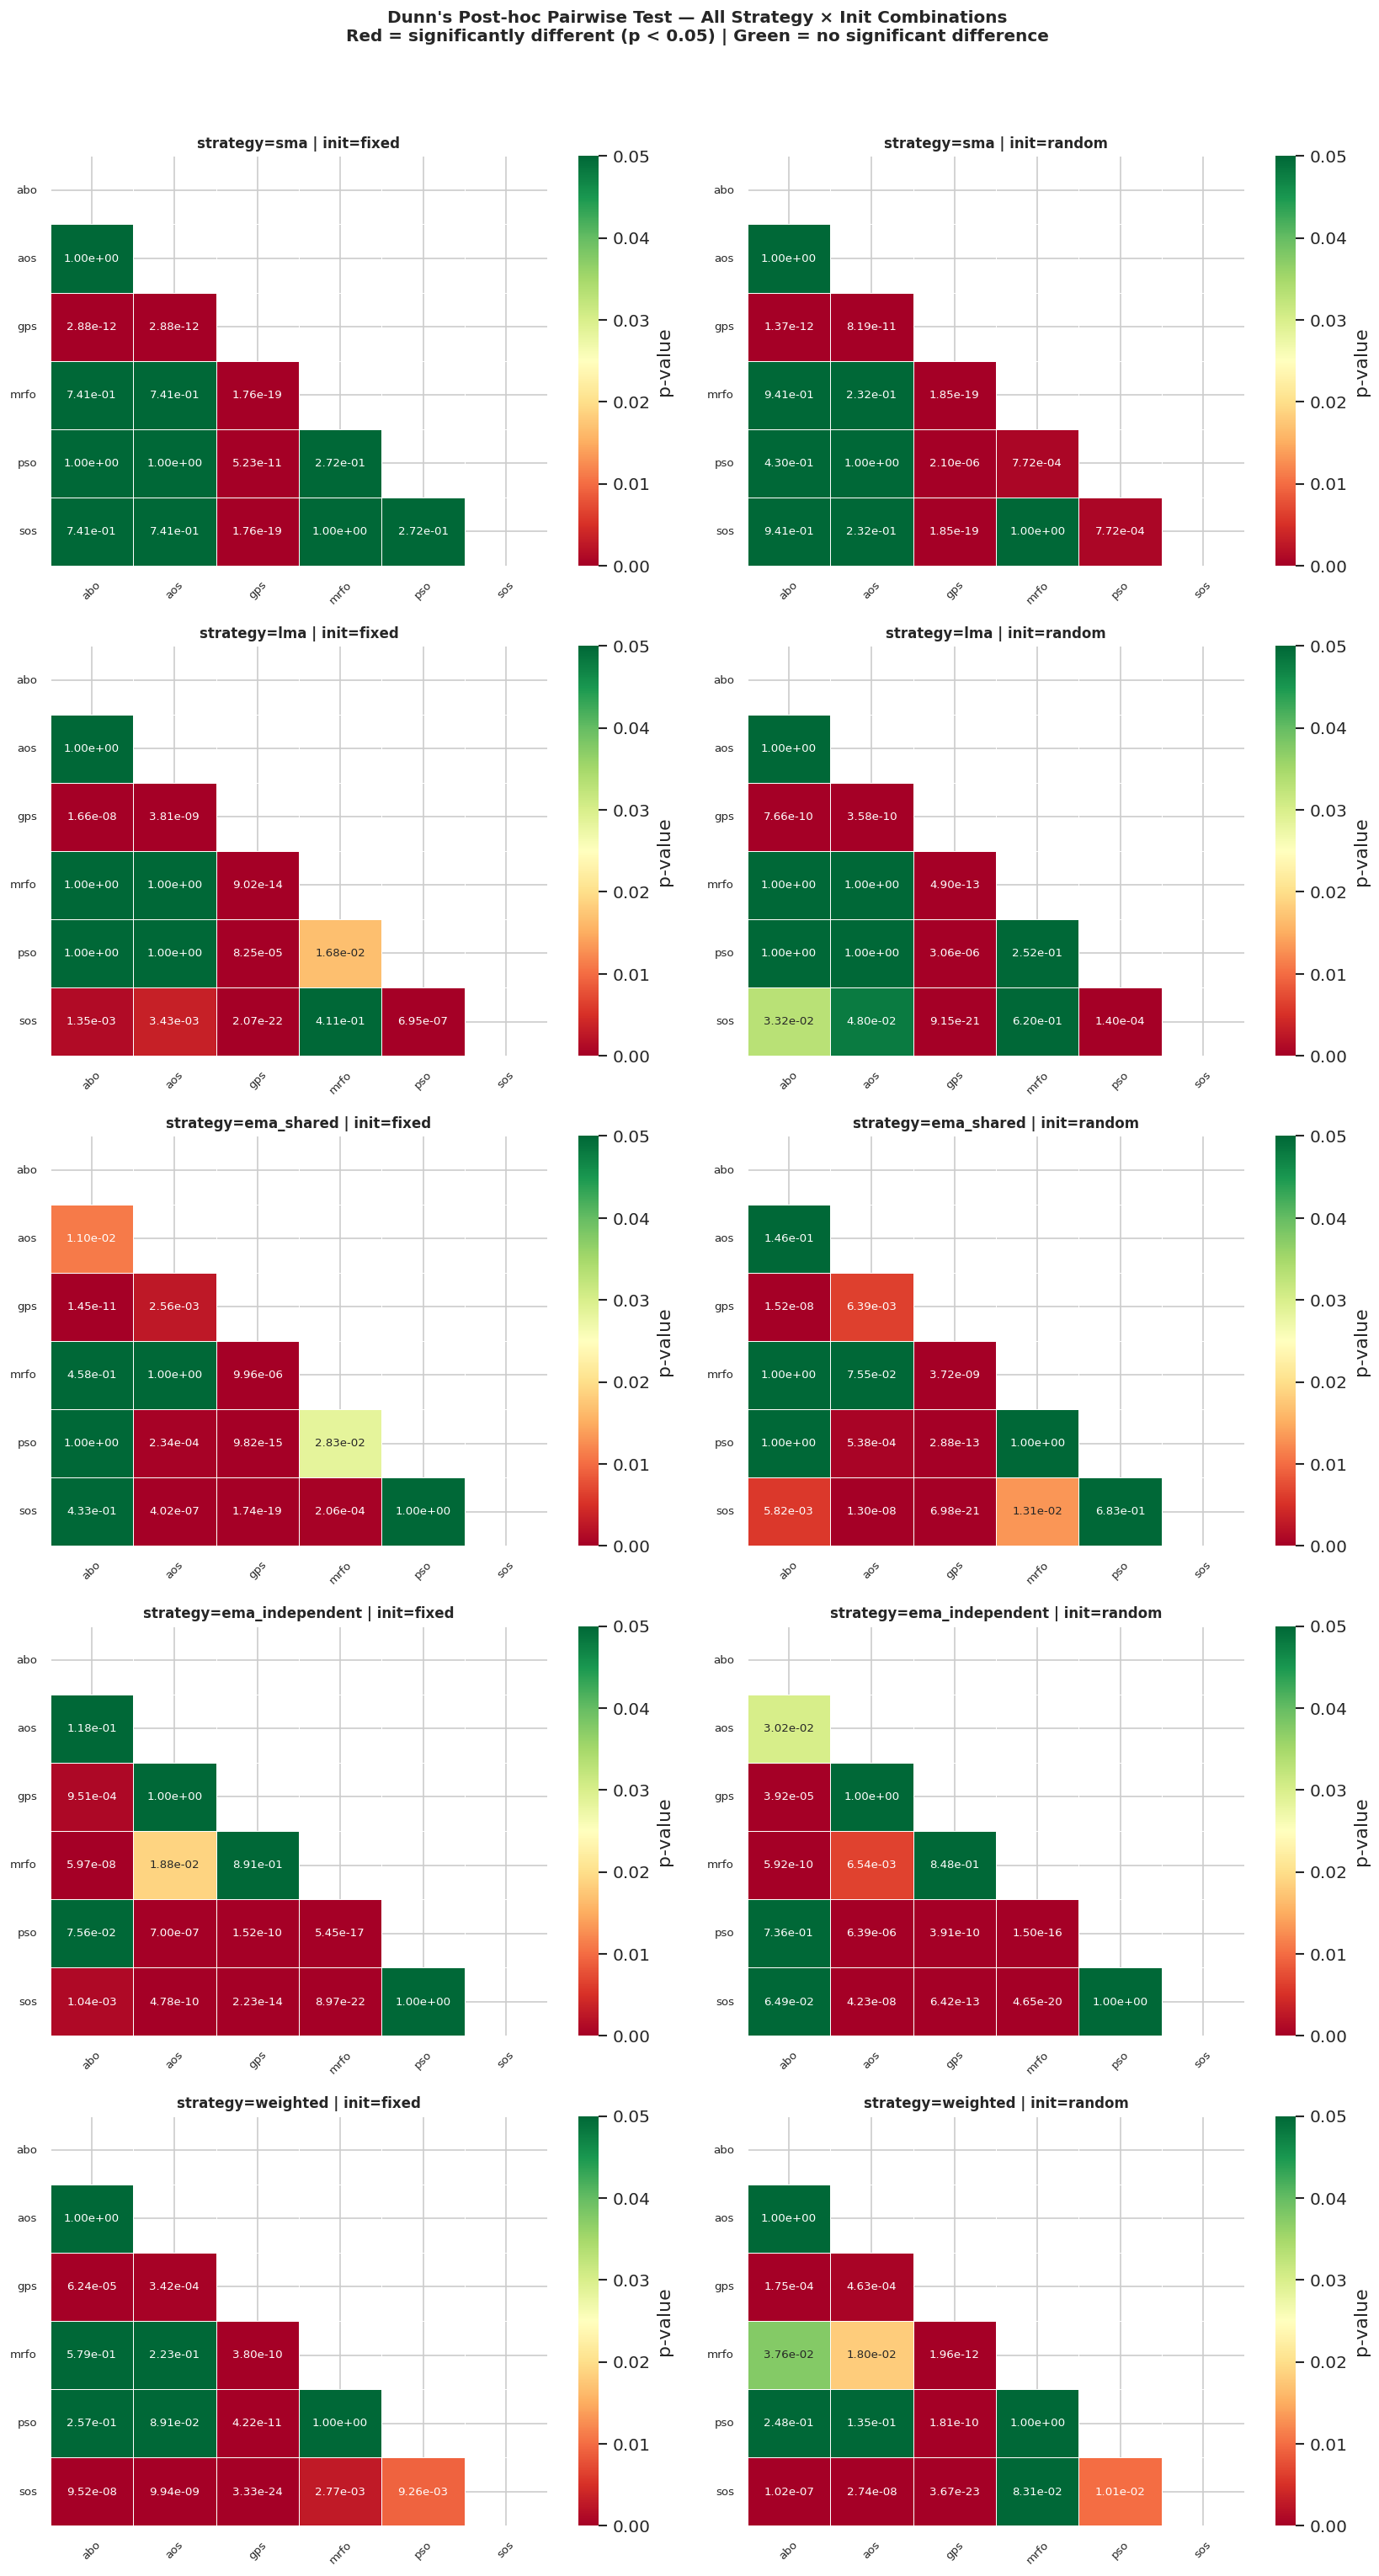

In [11]:
paired_posthoc('final_cash')

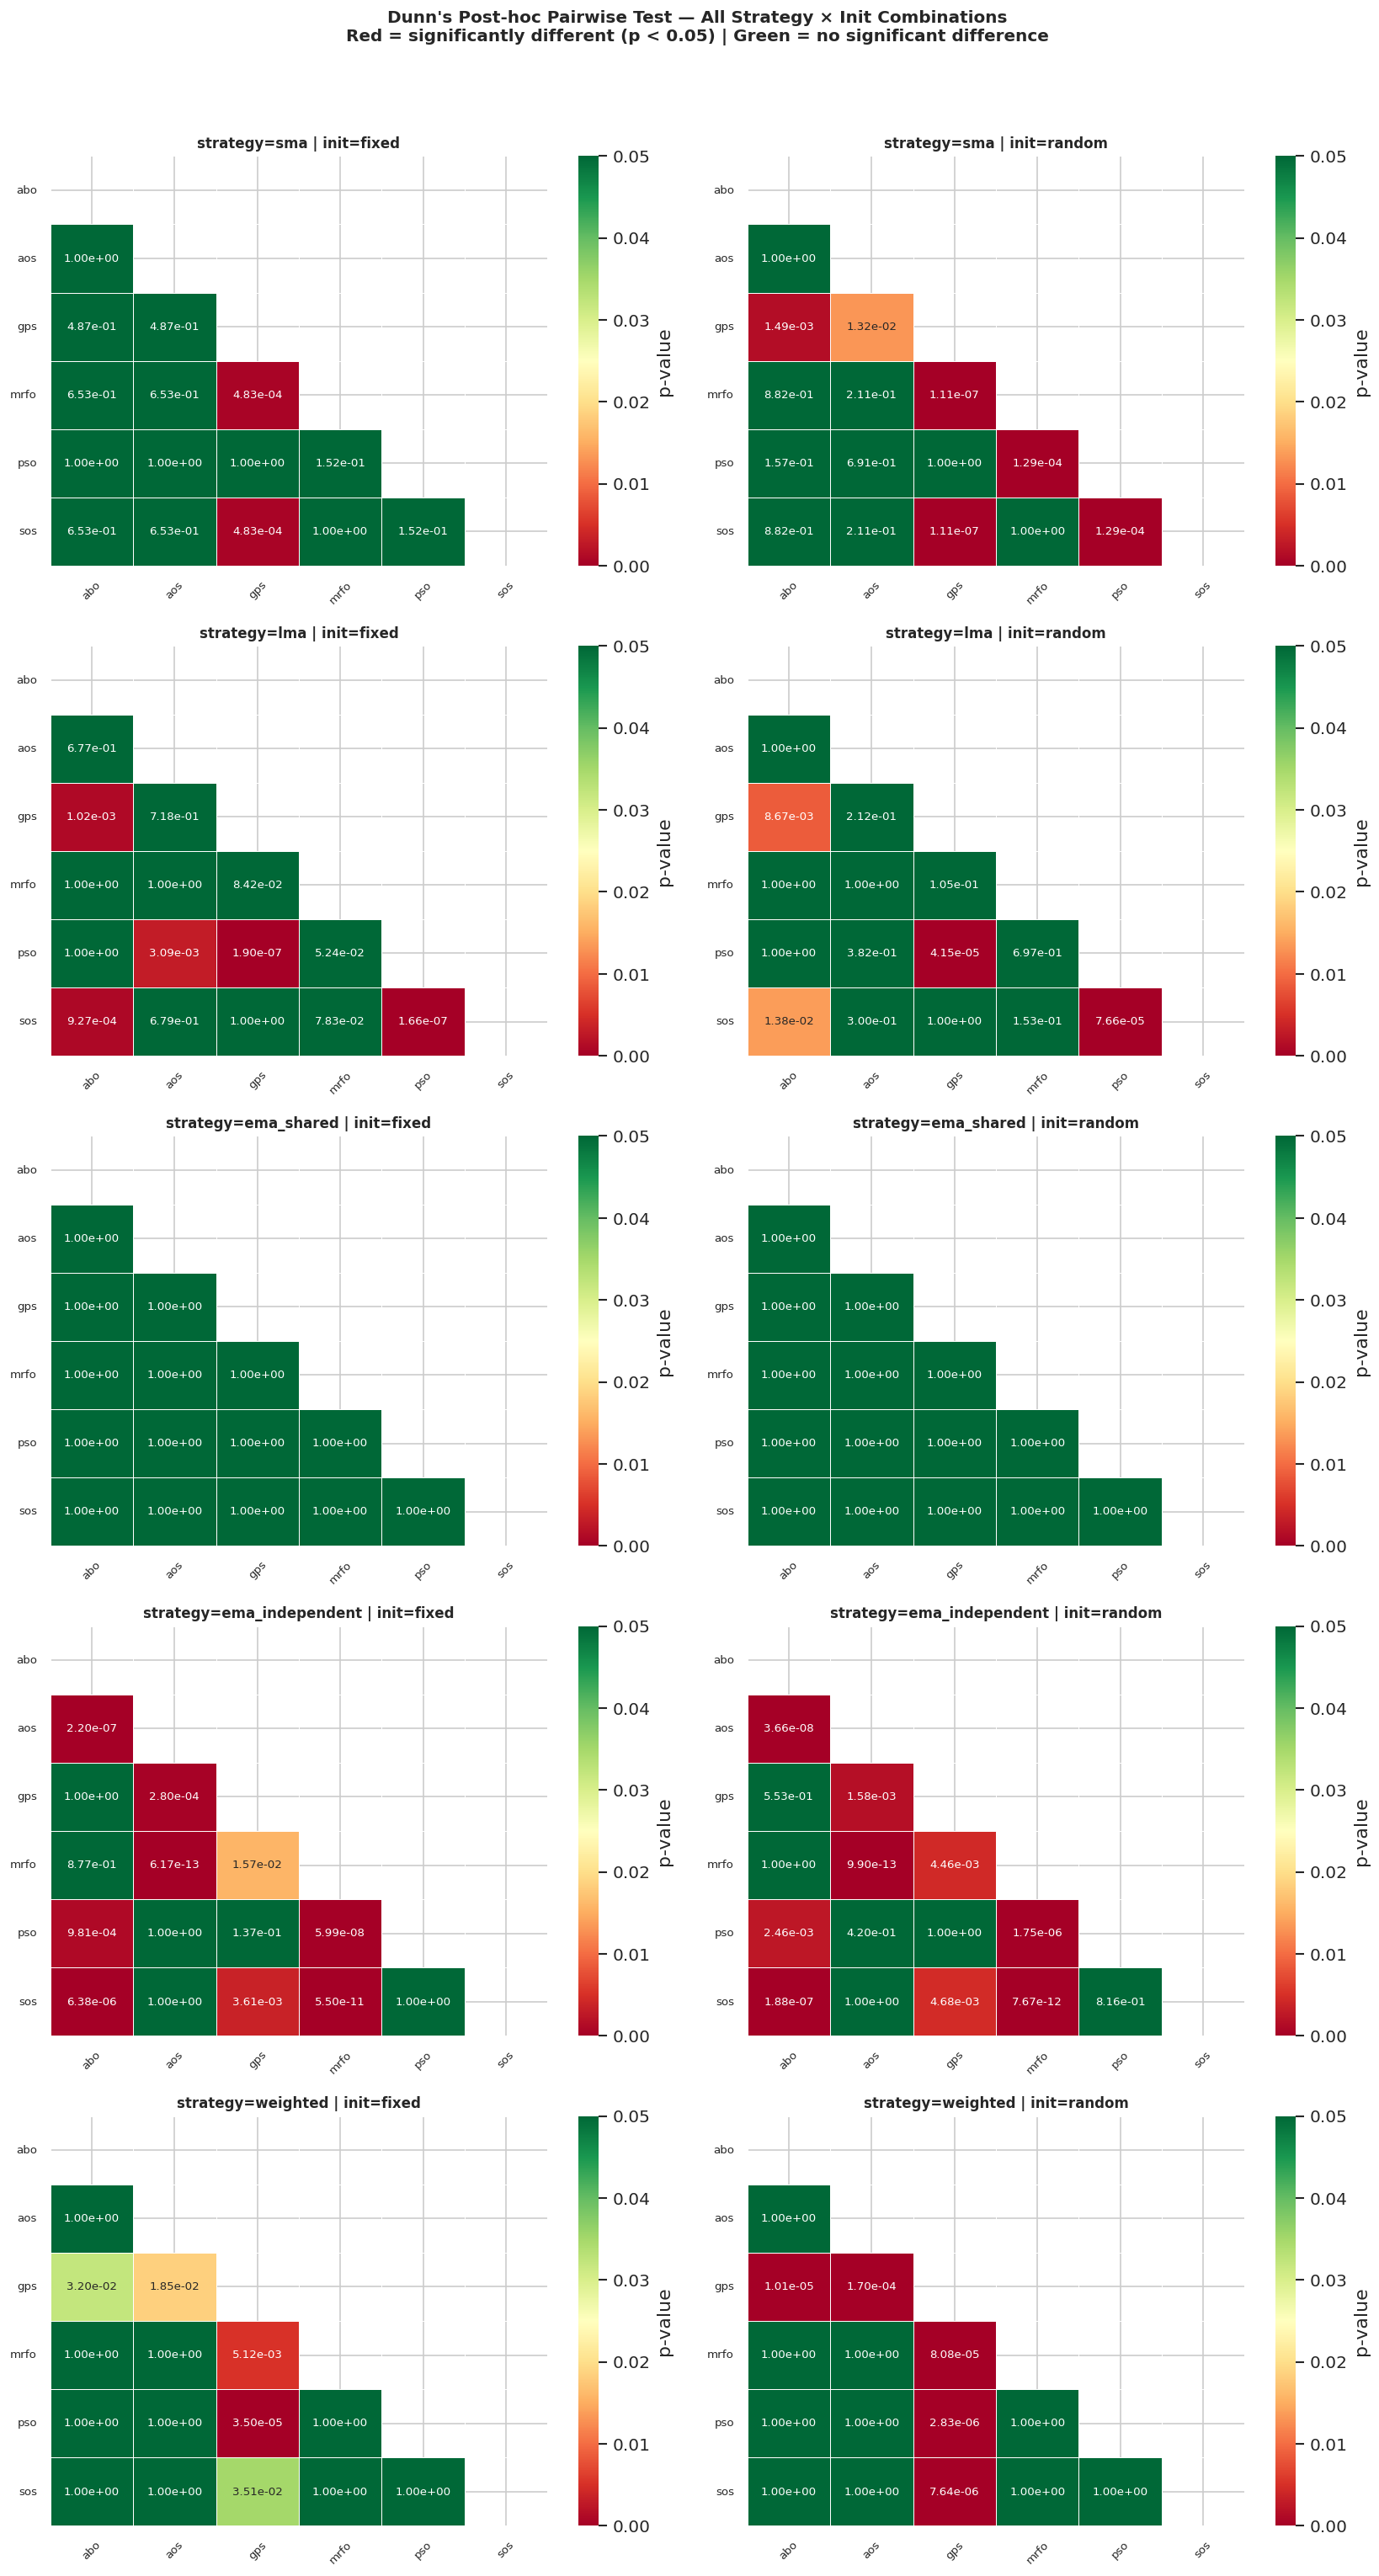

In [12]:
paired_posthoc('test_final_cash')

In [13]:
# for strategy in df['strategy'].unique():
#     for init in df['start_mode'].unique():
#         subset = df.query("strategy == @strategy and start_mode == @init")
#         medians = subset.groupby('algo')['best_fitness'].median().sort_values(ascending=False)
#         print(f"\n{strategy} | {init}")
#         display(medians)

Calculate the ratio between result medians with buy and hold benchmark

In [14]:
df['bnh_ratio'] = df['test_final_cash'] / BUY_AND_HOLD_BENCHMARK

Check how many passes the benchmark

In [15]:
passing_benchmark_df = df[df['bnh_ratio'] > 1.0].sort_values(by='bnh_ratio')

In [16]:
def check_how_many_passes(df, group_by="algo"):
    fixed_df = df[df["start_mode"] == "fixed"]
    random_df = df[df["start_mode"] == "random"]

    fixed_counts = fixed_df.groupby(group_by).size()
    random_counts = random_df.groupby(group_by).size()
    fixed_var = fixed_df.groupby(group_by)["bnh_ratio"].var()
    random_var = random_df.groupby(group_by)["bnh_ratio"].var()

    summary_df = pd.DataFrame(
        {"fixed_count": fixed_counts, "random_count": random_counts,
         "fixed_var": fixed_var, "random_var": random_var}
    )

    # Force the specific algorithms and order (fills missing with NaN)
    target = ["abo", "aos", "gps", "pso", "sos", "mrfo"] if group_by == 'algo' \
        else ['sma', 'lma', 'ema_shared', 'ema_independent', 'weighted']

    summary_df = summary_df.reindex(target)

    # Fill NaN values with 0 for counts, convert counts to integers
    summary_df[["fixed_count", "random_count"]] = summary_df[["fixed_count", "random_count"]].fillna(0).astype(int)

    # Calculate percentages (divided by 900)
    summary_df[f"% out of 900 fixed"] = (summary_df["fixed_count"] / 900) * 100
    summary_df[f"% out of 900 random"] = (summary_df["random_count"] / 900) * 100

    # Calculate percentage per trial (divided by 30)
    summary_df[f"% out of 30 fixed"] = (summary_df["fixed_count"] / 30) * 100
    summary_df[f"% out of 30 random"] = (summary_df["random_count"] / 30) * 100

    # Clean up column order for easy reading
    column_order = [
        "fixed_count",
        f"% out of 900 fixed",
        f"% out of 30 fixed",
        "fixed_var",
        "random_count",
        f"% out of 900 random",
        f"% out of 30 random",
        "random_var",
    ]

    summary_df = summary_df[column_order]
    return summary_df


display(check_how_many_passes(passing_benchmark_df, "algo").round(3))
display(check_how_many_passes(passing_benchmark_df, "strategy").round(3))

,fixed_count,% out of 900 fixed,% out of 30 fixed,fixed_var,random_count,% out of 900 random,% out of 30 random,random_var
algo,,,,,,,,
abo,2,0.222,6.667,0.003,5,0.556,16.667,0.025
aos,3,0.333,10.000,0.033,4,0.444,13.333,0.028
gps,1,0.111,3.333,NaN,0,0.000,0.000,NaN
pso,2,0.222,6.667,0.243,1,0.111,3.333,NaN
sos,2,0.222,6.667,0.001,2,0.222,6.667,0.022
mrfo,0,0.000,0.000,NaN,3,0.333,10.000,0.413


,fixed_count,% out of 900 fixed,% out of 30 fixed,fixed_var,random_count,% out of 900 random,% out of 30 random,random_var
strategy,,,,,,,,
sma,0,0.000,0.000,NaN,0,0.000,0.000,NaN
lma,0,0.000,0.000,NaN,0,0.000,0.000,NaN
ema_shared,5,0.556,16.667,0.083,7,0.778,23.333,0.13
ema_independent,4,0.444,13.333,0.025,1,0.111,3.333,NaN
weighted,1,0.111,3.333,NaN,7,0.778,23.333,0.00


In [17]:
ct = pd.crosstab(
    passing_benchmark_df['algo'],
    [passing_benchmark_df['strategy'], passing_benchmark_df['start_mode']]
)

# Add total row
ct.loc['total'] = ct.sum()

display(ct)


strategy   ema_independent        ema_shared        weighted       
start_mode           fixed random      fixed random    fixed random
algo                                                               
abo                      0      0          1      2        1      3
aos                      3      1          0      2        0      1
gps                      1      0          0      0        0      0
mrfo                     0      0          0      1        0      2
pso                      0      0          2      0        0      1
sos                      0      0          2      2        0      0
total                    4      1          5      7        1      7

# Plot the bar for test_final_cash

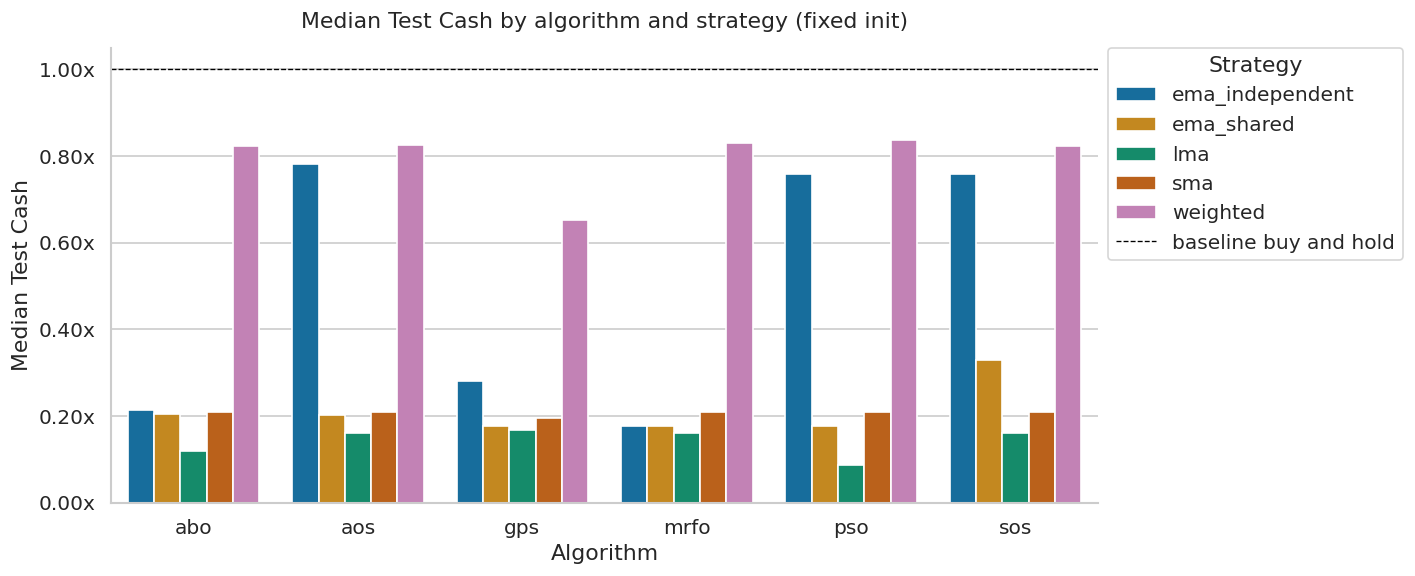

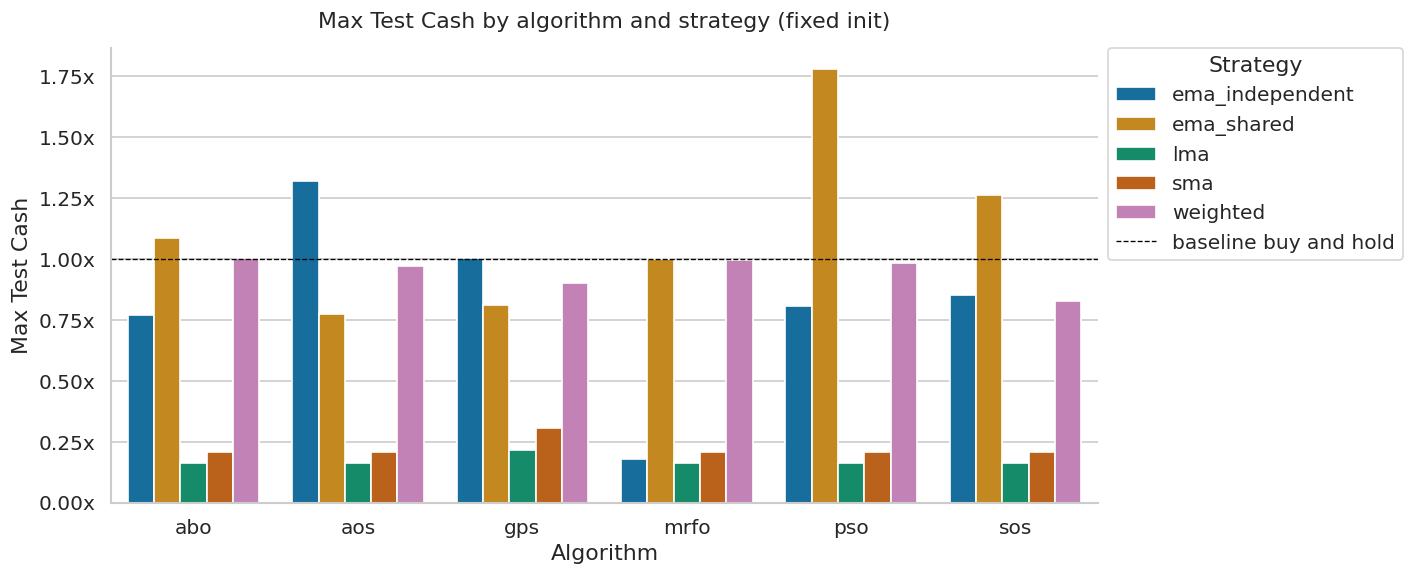

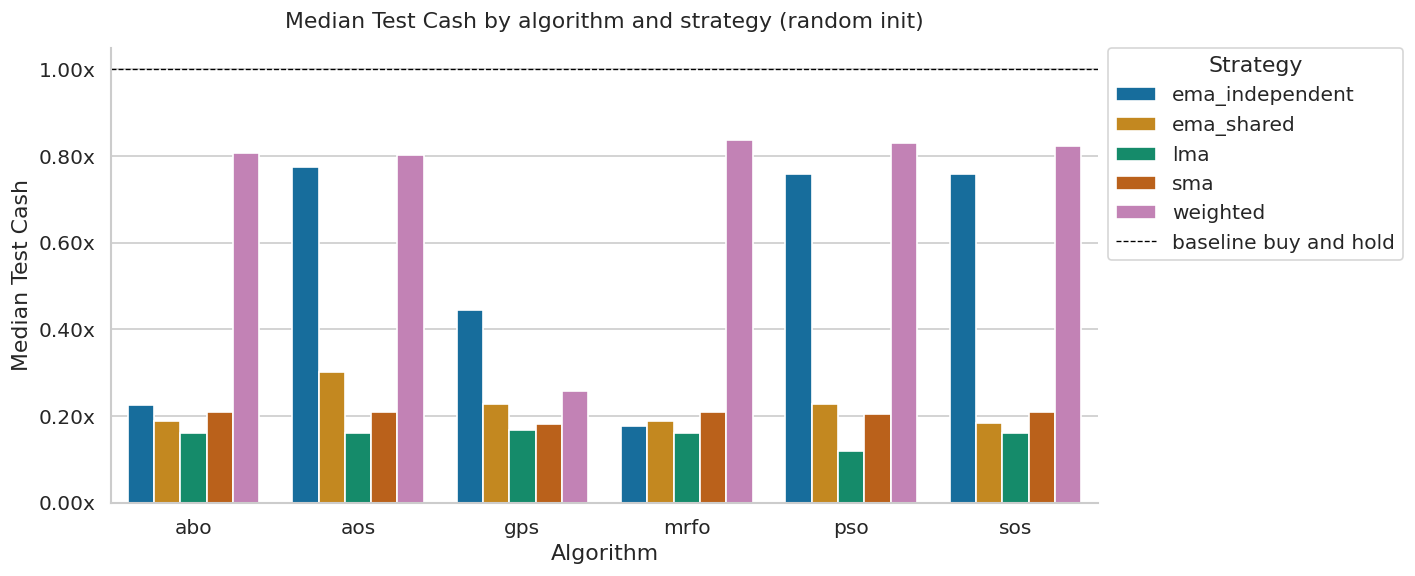

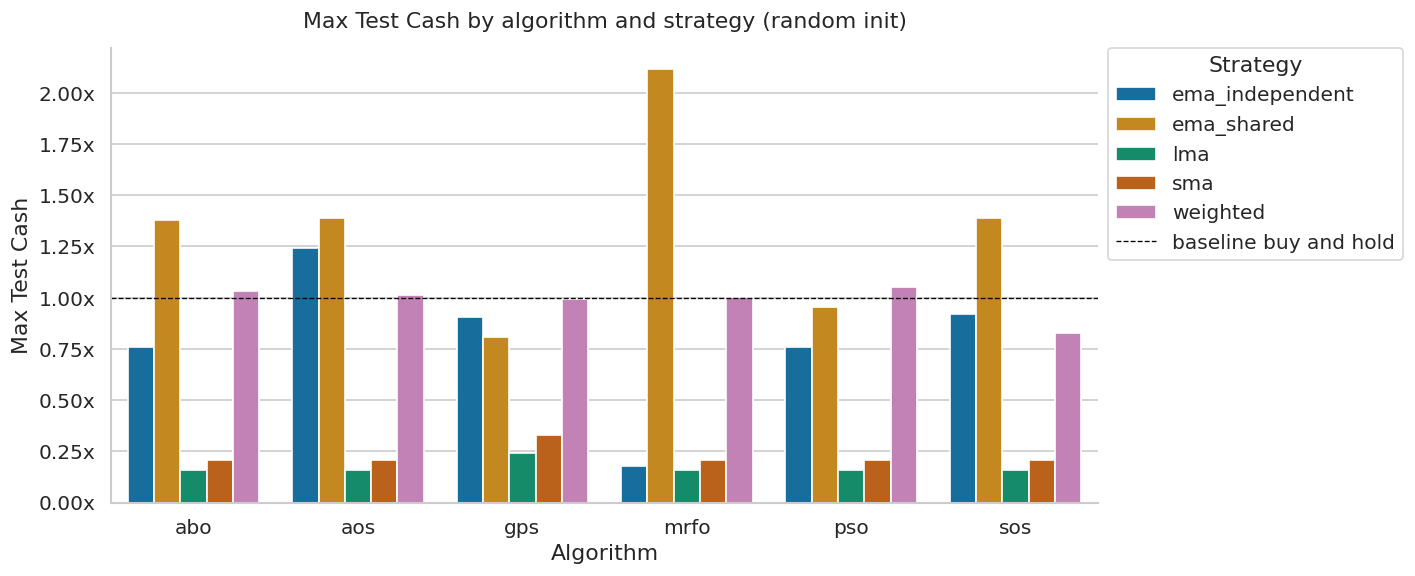

In [18]:

def plot_bar(data_points, plot_type, init_point):
    fig, ax = plt.subplots(figsize=(12, 5))

    sns.barplot(
        data=data_points,
        x='algo',
        y='bnh_ratio',
        hue='strategy',
        palette='colorblind',   # distinguishable without relying on red/green
        ax=ax
    )

    # Reference line
    ax.axhline(1, color='black', linewidth=0.8, linestyle='--', label='baseline buy and hold')

    ax.set_title(f'{plot_type} by algorithm and strategy ({init_point} init)', pad=12)
    ax.set_xlabel('Algorithm')
    ax.set_ylabel(f'{plot_type}')
    ax.legend(title='Strategy', bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.2f}x'))

    plt.tight_layout()
    plt.show()

def group_data(df, initial_mode='fixed', group_type='median'):
    grouped_data = (
        df[df['start_mode'] == initial_mode]
        .groupby(['algo', 'strategy'])['bnh_ratio']
        .agg(group_type)
        .reset_index()
    )
    return grouped_data

plot_bar(group_data(df, initial_mode='fixed', group_type='median'),
    plot_type='Median Test Cash', init_point='fixed')

plot_bar(group_data(df, initial_mode='fixed', group_type='max'),
    plot_type='Max Test Cash', init_point='fixed')

plot_bar(group_data(df, initial_mode='random', group_type='median'),
    plot_type='Median Test Cash', init_point='random')
    
plot_bar(group_data(df, initial_mode='random', group_type='max'),
    plot_type='Max Test Cash', init_point='random')

## Spearman ρ(train_fitness, test_fitness) per Strategy

This is pooled across both fixed and random

/tmp/ipykernel_12883/2231378837.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(strategies, rotation=15, ha="right")
/tmp/ipykernel_12883/2231378837.py:46: UserWarning: Mismatched number of handles and labels: len(handles) = 5 len(labels) = 1
  ax.legend(handles=[ax.get_legend_handles_labels()[0][0]] + legend_items,


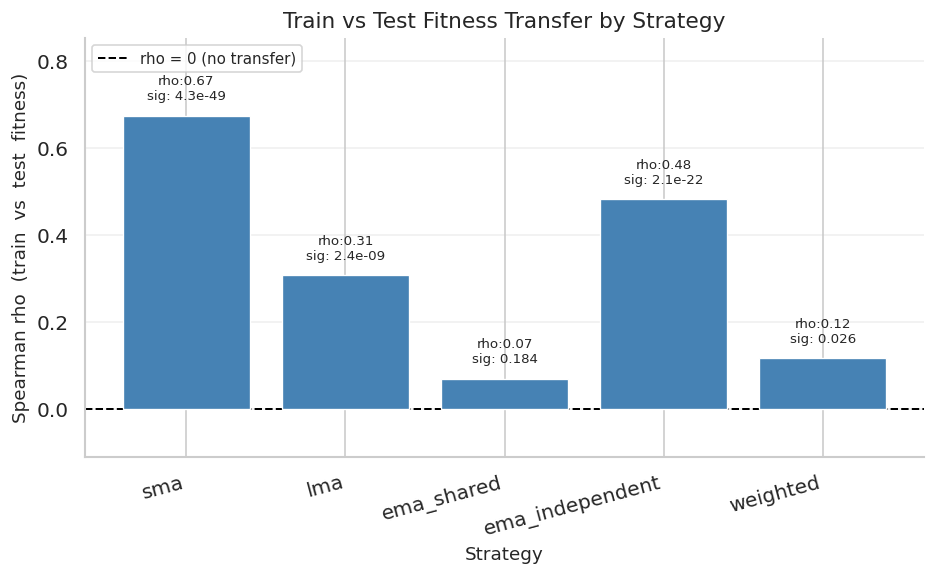

In [19]:
from scipy.stats import spearmanr

strategies = ["sma", "lma", "ema_shared", "ema_independent", "weighted"]

rhos, pvals = [], []
for s in strategies:
    sub = df[df["strategy"] == s]
    rho, p = spearmanr(sub["final_cash"], sub["test_final_cash"])
    rhos.append(rho)
    pvals.append(p)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(strategies, rhos, color="steelblue", edgecolor="white", linewidth=0.8, zorder=3)

for bar, rho, p in zip(bars, rhos, pvals):
    yoff = 0.03 if rho >= 0 else -0.06

    p_text = f"{p:.1e}" if p < 0.001 else f"{p:.3f}"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        rho + yoff,
        f'rho:{round(rho, 2)}\nsig: {p_text}',
        ha="center", va="bottom", fontsize=8,
    )

ax.axhline(0, color="black", linestyle="--", linewidth=1.2, label="rho = 0 (no transfer)", zorder=2)

ax.set_ylabel("Spearman rho  (train  vs  test  fitness)", fontsize=11)
ax.set_xlabel("Strategy", fontsize=11)
ax.set_title("Train vs Test Fitness Transfer by Strategy", fontsize=13)
ax.set_ylim(min(rhos) - 0.18, max(rhos) + 0.18)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3, zorder=0)
ax.set_xticklabels(strategies, rotation=15, ha="right")

# Significance legend
from matplotlib.lines import Line2D
legend_items = [
    Line2D([0], [0], color="none", label="*** p < 0.001"),
    Line2D([0], [0], color="none", label="**  p < 0.01"),
    Line2D([0], [0], color="none", label="*   p < 0.05"),
    Line2D([0], [0], color="none", label="ns  p ≥ 0.05"),
]
ax.legend(handles=[ax.get_legend_handles_labels()[0][0]] + legend_items,
          labels=["rho = 0 (no transfer)"],
          fontsize=9, loc="upper left")

plt.tight_layout()
plt.savefig("spearman_train_test_per_strategy.png", dpi=150)
plt.show()


When checking with spreadsheet, on `ema_shared` with `mrfo` on both random and fixed init there are 2 entries with 5660ish profit that got excluded from the result. Those are mrfo run 14 (fixed) and 1 (random).

Let's try visualizing the plot



In [20]:
mrfo_14 = df.query('algo == "mrfo" & strategy == "ema_shared" & run_id == 14 & start_mode == "fixed"')
mrfo_1 = df.query('algo == "mrfo" & strategy == "ema_shared" & run_id == 14 & start_mode == "random"')

from runners.mrfo.plot import plot_equity_and_purchases
from runners.mrfo.common import re_evaluate
from runners.mrfo.ema import get_signals_shared
import json

best_params_json = mrfo_1["best_params"].iloc[0]
short, long, buy_at, sell_at, equity_curve, cash = \
    re_evaluate(json.loads(best_params_json), train_prices, get_signals_shared)

sns.lineplot(mrfo_1["equity_curve"].iloc[0])

<Axes: >

In [24]:
pso_15 = df.query('algo == "pso" & strategy == "ema_shared" & run_id == 15 & start_mode == "fixed"')

from runners.pso.common import re_evaluate
from runners.pso.ema import get_signals_shared
import json

best_params_json = pso_15["best_params"].iloc[0]
short, long, buy_at, sell_at, equity_curve, cash = \
    re_evaluate(json.loads(best_params_json), train_prices, get_signals_shared)

print(buy_at)
print(sell_at)

[(47, np.float64(162.0))]
[(1173, np.float64(8522.99))]


# Aggregate and Save

In [ ]:
# agg_funcs = ["mean", "median", "std", lambda x: x.std() / x.mean(), "min", "max"]
# agg_names  = ["mean", "median", "std", "cv", "min", "max"]

# def summarise(df, cols):
#     return (
#         df.groupby(["strategy", "algo"])[cols]
#         .agg(agg_funcs)
#         .set_axis(
#             pd.MultiIndex.from_product([cols, agg_names]),
#             axis=1,
#         )
#     )

# # Table 1 — cash performance
# print("=== Fixed — Cash ===")
# display(summarise(fixed_results, ["final_cash", "test_final_cash"]))

# print("=== Random — Cash ===")
# display(summarise(random_results, ["final_cash", "test_final_cash"]))

# # Table 2 — runtime & epochs
# print("=== Fixed — Runtime / Epochs ===")
# display(summarise(fixed_results, ["runtime_ms", "epoch_count"]))

# print("=== Random — Runtime / Epochs ===")
# display(summarise(random_results, ["runtime_ms", "epoch_count"]))

In [ ]:
# summary_fixed_cash    = summarise(fixed_results,  ["final_cash", "test_final_cash"])
# summary_random_cash   = summarise(random_results, ["final_cash", "test_final_cash"])
# summary_fixed_runtime = summarise(fixed_results,  ["runtime_ms", "epoch_count"])
# summary_random_runtime = summarise(random_results, ["runtime_ms", "epoch_count"])

# summary_fixed_cash.to_csv("results/summary_fixed_cash.csv")
# summary_random_cash.to_csv("results/summary_random_cash.csv")
# summary_fixed_runtime.to_csv("results/summary_fixed_runtime.csv")
# summary_random_runtime.to_csv("results/summary_random_runtime.csv")

# print("Summaries saved to results/")